In [5]:
pip install "truckscenes-devkit[all]"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import os
for item in os.listdir("C:/Users/laila/Documents/dataman-truckscenes/man-truckscenes"):
    print(item)

samples
sweeps
v1.2-mini


In [7]:
from truckscenes import TruckScenes

trucksc = TruckScenes(version='v1.2-mini', dataroot='C:/Users/laila/Documents/dataman-truckscenes/man-truckscenes', verbose=True)

Loading truckscenes tables for version v1.2-mini...
11 attribute,
18 calibrated_sensor,
27 category,
20090 ego_motion_cabin,
20089 ego_motion_chassis,
20116 ego_pose,
1094 instance,
400 sample,
25750 sample_annotation,
43556 sample_data,
10 scene,
18 sensor,
4 visibility,
Done loading in 1.525 seconds.
Reverse indexing ...
Done reverse indexing in 0.2 seconds.
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [8]:
# List all scenes
trucksc.list_scenes()

# Look at a single scene's metadata
scene = trucksc.scene[0]
print(scene)

# Step through samples (keyframes) in a scene
sample = trucksc.get('sample', scene['first_sample_token'])
print(sample)

[23-08-24 09:09:31] scene-3195e3bfd1de4f9ba82f874790c7856c-15: length: 19.50s, #anns: 1500, desc: weather.overcast;area.highway;daytime.noon;season.s...
[23-08-26 08:13:49] scene-3f542f89ec5241b6a4e30ca743adcf34-29: length: 19.50s, #anns: 3291, desc: weather.overcast;area.highway;daytime.morning;seaso...
[23-09-17 08:19:52] scene-6be74229febb4aad9e7ae1a37217b231-4: length: 19.50s, #anns: 621, desc: weather.rain;area.terminal;daytime.morning;season.s...
[23-09-23 12:49:32] scene-0044384af3d8494e913fb8b14915239e-3: length: 19.50s, #anns: 1264, desc: weather.clear;area.terminal;daytime.noon;season.aut...
[23-10-07 17:35:24] scene-13f4b71b1bd04a9e88747ad8f58a3f67-4: length: 19.50s, #anns: 1252, desc: weather.clear;area.highway;daytime.evening;season.a...
[23-11-14 14:59:34] scene-b201f6e737e34c2d87830fc1e2911516-6: length: 19.50s, #anns: 2902, desc: weather.rain;area.highway;daytime.noon;season.autum...
[23-11-28 12:22:50] scene-b13542304b244af585a646082c57a079-1: length: 19.50s, #anns: 24

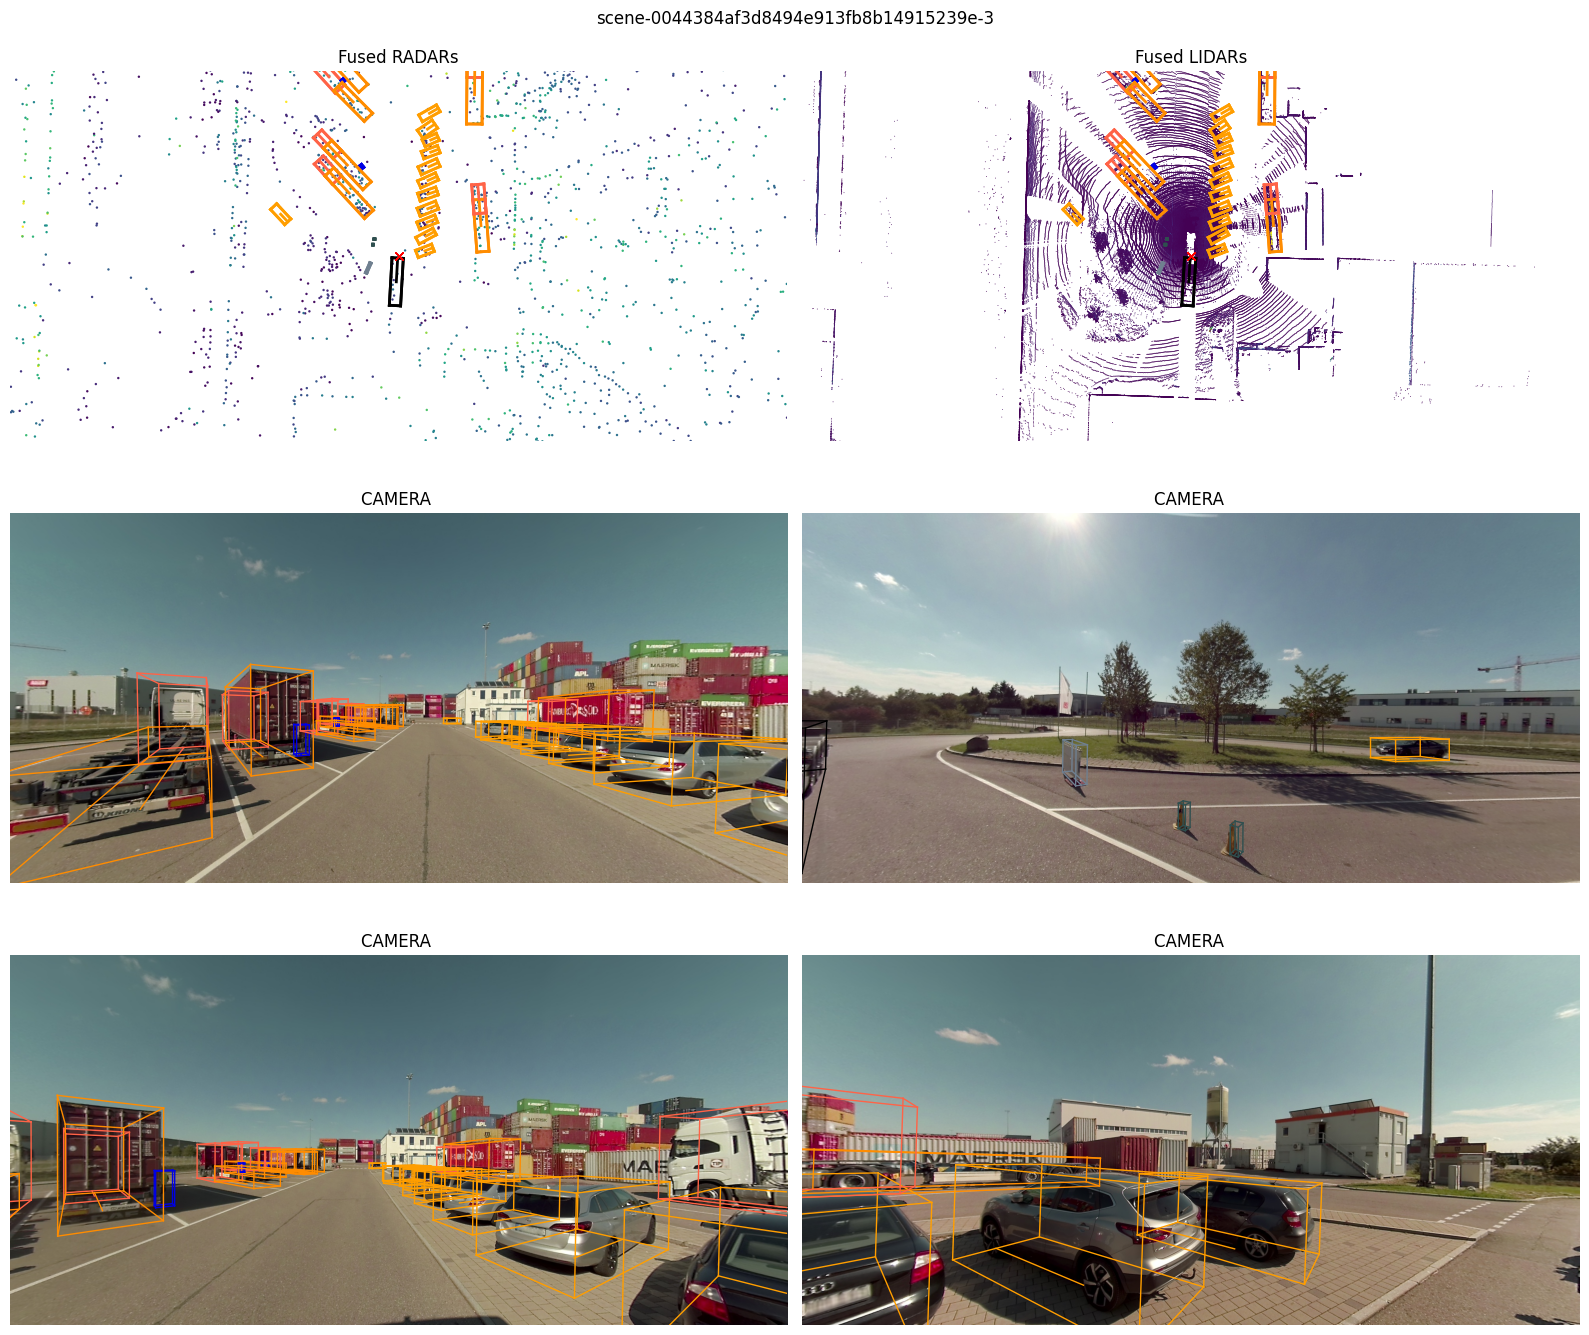

In [9]:
trucksc.render_sample(sample['token'])

In [10]:
trucksc.render_scene(scene['token'])

In [11]:
# Get all annotations in a sample
for ann_token in sample['anns']:
    ann = trucksc.get('sample_annotation', ann_token)
    print(ann['category_name'], ann['translation'], ann['size'])

# Category counts across dataset
from collections import Counter
cats = Counter(trucksc.get('sample_annotation', t)['category_name']
                for s in trucksc.sample for t in s['anns'])
print(cats)

vehicle.car [571701.2157594472, 5367870.003885938, 594.4508582291495] [1.66326, 3.745129, 1.473757]
human.pedestrian.adult [571681.1614054472, 5367896.964050937, 594.2002642291496] [1.020549, 0.54785, 1.512545]
vehicle.truck [571679.4456804473, 5367891.611284938, 595.8145682291495] [2.623641, 5.752715, 3.936521]
human.pedestrian.adult [571686.2474364472, 5367866.832435938, 594.3013332291495] [0.705147, 0.805016, 1.761119]
vehicle.trailer [571682.3904744472, 5367888.463594938, 594.2163822291495] [2.579103, 12.62135, 1.662046]
vehicle.truck [571679.7616094472, 5367901.225441937, 595.3040612291495] [2.597283, 5.971582, 4.026235]
movable_object.trafficcone [571689.0546474472, 5367851.218077937, 594.1533112291495] [0.133719, 0.198518, 0.45974]
vehicle.truck [571678.9121044473, 5367871.725052938, 595.2990982291496] [2.492282, 6.157837, 4.0779]
vehicle.trailer [571712.0840394472, 5367854.141432937, 594.9828882291496] [2.626044, 11.305927, 1.692497]
vehicle.trailer [571685.5873364472, 5367905.

In [12]:
instance = trucksc.instance[0]
ann_token = instance['first_annotation_token']
while ann_token:
    ann = trucksc.get('sample_annotation', ann_token)
    print(ann['translation'])
    ann_token = ann['next']

[571701.2157594472, 5367870.003885938, 594.4508582291495]
[571701.2495592021, 5367869.939043226, 594.3730306259563]
[571701.2532455809, 5367869.854141489, 594.3591121614858]
[571701.2668880171, 5367869.9066620795, 594.5291547660688]
[571701.2045056748, 5367869.895298283, 594.641057279175]
[571701.3086149142, 5367869.872721316, 594.7389812686338]
[571701.3337972751, 5367869.93870392, 594.793910996088]
[571701.3898588618, 5367869.920319663, 594.8616453387712]
[571701.413966223, 5367869.903281878, 595.0020457900017]
[571701.3624722634, 5367869.950215914, 594.9464861991742]
[571701.3690660872, 5367870.01824899, 594.8546415771353]
[571701.3740736593, 5367870.08807243, 594.8936392675854]
[571701.330045361, 5367870.067576637, 594.6006064573737]
[571701.1910698904, 5367870.05712202, 594.6453927961061]
[571701.3763172487, 5367870.096824608, 594.6337489618613]
[571701.2751979296, 5367870.125066052, 594.622391671045]
[571701.3193432337, 5367870.080142388, 594.6785003214214]
[571701.3881871748, 53

In [13]:
import numpy as np
poses = [trucksc.get('ego_pose', trucksc.get('sample_data', sd['token'])['ego_pose_token'])
         for sd in trucksc.sample_data if sd['is_key_frame']]
xy = np.array([p['translation'][:2] for p in poses])

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
records = []
for ann in trucksc.sample_annotation:
    records.append({
        'category': ann['category_name'],
        'num_lidar_pts': ann['num_lidar_pts'],
        'num_radar_pts': ann['num_radar_pts'],
        'visibility': ann['visibility_token'],
        'size': ann['size'],
    })

df = pd.DataFrame(records)
print(df.columns.tolist())

['category', 'num_lidar_pts', 'num_radar_pts', 'visibility', 'size']


In [20]:
#Average point counts per category (detectability metric)
summary = df.groupby('category').agg(
    count=('category', 'size'),
    mean_lidar_pts=('num_lidar_pts','mean'),
    median_lidar_pts=('num_lidar_pts', 'median'),
    mean_radar_pts=('num_radar_pts', 'mean'),
    pct_zero_lidar=('num_lidar_pts', lambda x: (x == 0).mean() * 100),
    pct_zero_radar=('num_radar_pts', lambda x: (x == 0).mean() * 100),
).sort_values('mean_lidar_pts', ascending=False)
print(summary)

                                      count  mean_lidar_pts  median_lidar_pts  \
category                                                                        
vehicle.train                           200    13990.175000           12030.5   
vehicle.ego_trailer                     360     7025.894444            7034.0   
vehicle.trailer                        1468     2245.331063             172.0   
vehicle.truck                          2230     1702.330045             148.5   
vehicle.construction                    132      832.356061              77.0   
vehicle.bus.rigid                       379      480.277045             103.0   
vehicle.other                            67      262.597015             267.0   
vehicle.car                           11811      233.042926              25.0   
vehicle.motorcycle                       80      226.512500              49.0   
vehicle.bicycle                         134      155.932836              57.0   
static_object.traffic_sign  

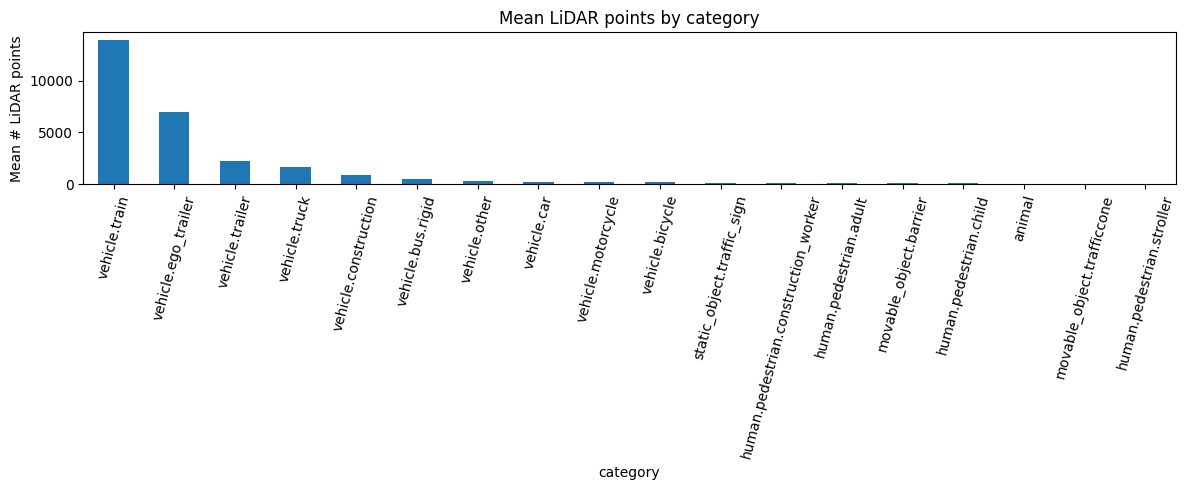

In [21]:
#Plotting
summary['mean_lidar_pts'].plot(kind='bar', figsize=(12,5), title='Mean LiDAR points by category')
plt.ylabel('Mean # LiDAR points')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [22]:
#Detectability Distance
def get_ann_distance(ann):
    sample = trucksc.get('sample', ann['sample_token'])
    ego_pose = trucksc.get('ego_pose', trucksc.get('sample_data',
         sample['data']['LIDAR_TOP_FRONT'])['ego_pose_token'])
    ego_xy = np.array(ego_pose['translation'][:2])
    ann_xy = np.array(ann['translation'][:2])
    return np.linalg.norm(ann_xy - ego_xy)

df['distance'] = [get_ann_distance(a) for a in trucksc.sample_annotation]

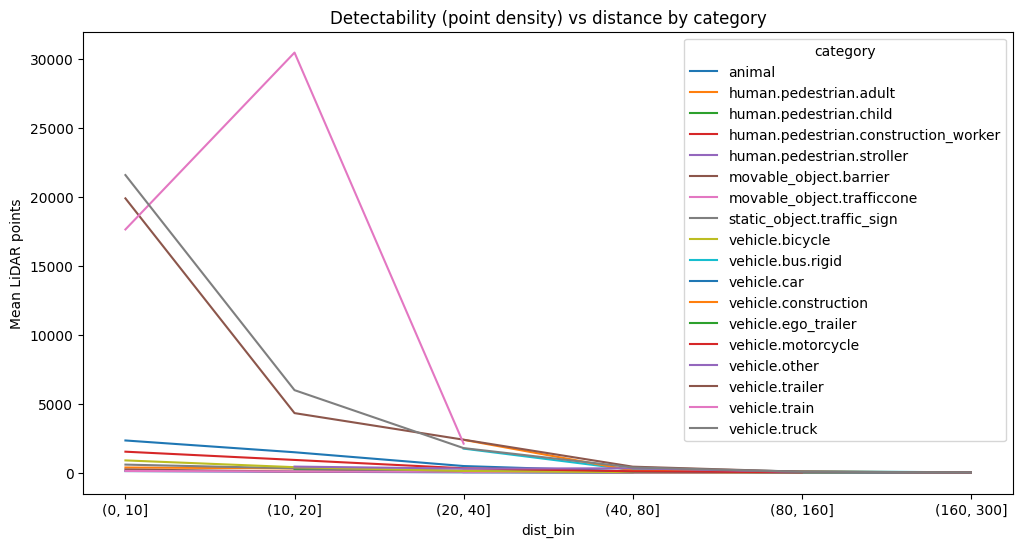

In [23]:
df['dist_bin'] = pd.cut(df['distance'], bins=[0,10,20,40,80,160,300])
pivot = df.pivot_table(index='dist_bin', columns='category', values='num_lidar_pts', aggfunc='mean')
pivot.plot(figsize=(12,6))
plt.ylabel('Mean LiDAR points')
plt.title('Detectability (point density) vs distance by category')
plt.show()

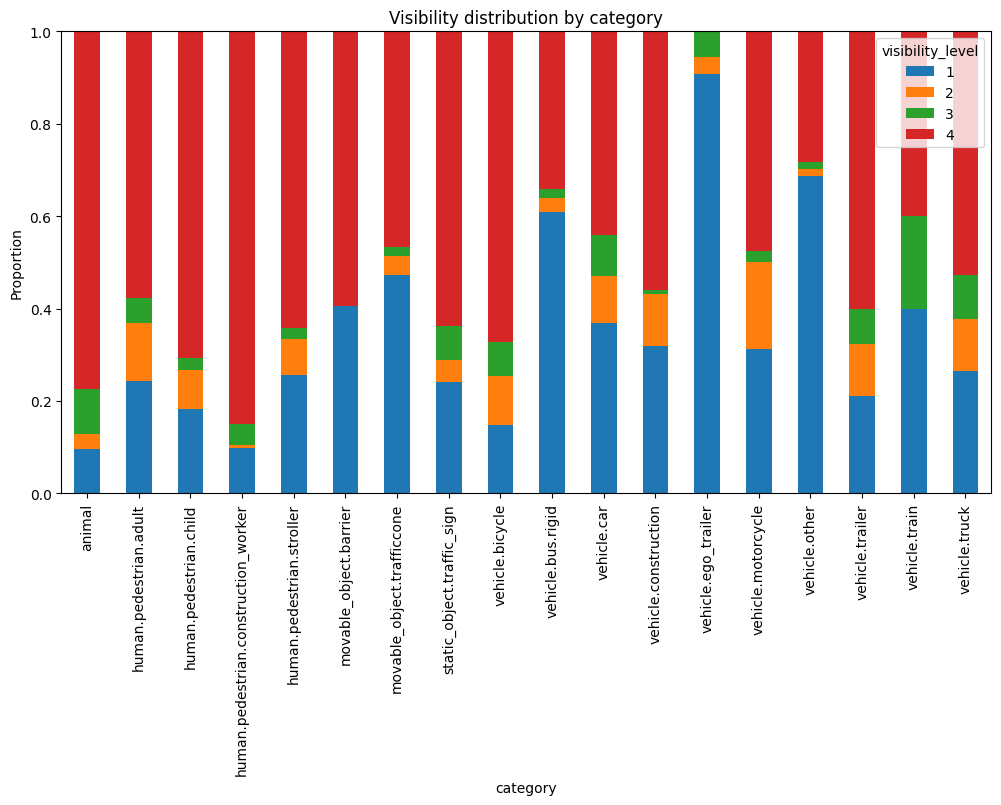

In [25]:
#Visiblity
vis_map = {t['token']: t['level'] for t in trucksc.visibility}
df['visibility_level'] = df['visibility'].map(vis_map)

pd.crosstab(df['category'], df['visibility_level'], normalize='index').plot(
    kind='bar', stacked=True, figsize=(12,6))
plt.ylabel('Proportion')
plt.title('Visibility distribution by category')
plt.show()

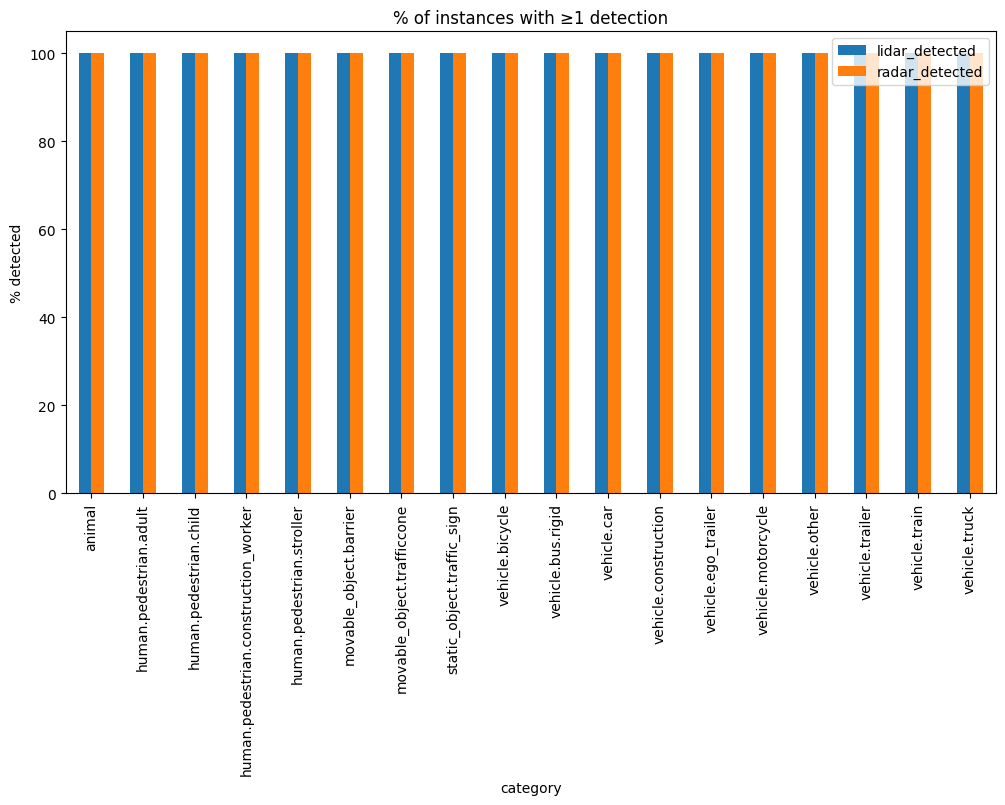

In [26]:
#RADAR Specific Detectability
df['lidar_detected'] = df['num_lidar_pts'] > 0
df['radar_detected'] = df['num_lidar_pts'] > 0

detect_rate = df.groupby('category')[['lidar_detected','radar_detected']].mean() * 100
detect_rate.plot(kind='bar', figsize=(12,6), title='% of instances with ≥1 detection')
plt.ylabel('% detected')
plt.show()

In [27]:
#Object size analysis
df[['width', 'length', 'height']] = pd.DataFrame(df['size'].tolist(), index=df.index)
df.groupby('category')[['width','length','height']].mean()
df.groupby('category')[['width','length','height']].std()  

,width,length,height
category,,,
animal,0.000000,0.000000,0.000000
human.pedestrian.adult,0.161521,0.174198,0.225653
human.pedestrian.child,0.260749,0.225512,0.138135
human.pedestrian.construction_worker,0.116445,0.084129,0.061437
human.pedestrian.stroller,0.000000,0.000000,0.000000
movable_object.barrier,0.946386,0.956678,0.164605
movable_object.trafficcone,0.148349,0.177864,0.445020
static_object.traffic_sign,2.952580,0.251241,1.267223
vehicle.bicycle,0.188097,0.192978,0.390063


In [28]:
#Attribute analysis
attr_map = {a['token']: a['name'] for a in trucksc.attribute}
df['attributes'] = [[attr_map[t] for t in ann['attribute_tokens']] for ann in trucksc.sample_annotation]
df.explode('attributes')['attributes'].value_counts()

attributes
vehicle.moving               10218
traffic_sign.pole_mounted     6297
vehicle.parked                4523
vehicle.stopped               1679
pedestrian.moving             1086
traffic_sign.overhanging       262
pedestrian.standing            199
cycle.with_rider               171
traffic_sign.temporary         134
cycle.without_rider             43
Name: count, dtype: int64